# IITM Reinforcement Learning Course Project — Final Notebook

**Course:** IITM Web M.Tech Program — Course ID 6002W  
**Project:** Industrial Inventory Control using Reinforcement Learning  
**Roll number:** DA25M579  
**Assigned parameter variant:** V030

This notebook is the final reproducibility and evidence record for the five distinct techniques
selected for the leaderboard. Rejected experiments are documented as concise text in
`EXPERIMENT_HISTORY.md`; failed code and stale checkpoints are intentionally excluded from the
final release.

All reported validation costs use the official unshaped environment cost. Training-time reward
shaping is used only as described in the training pipeline.


## 1. Course requirements covered

The notebook covers the assigned configuration, common state preprocessing/action mapping,
technique-specific representations, important hyperparameters, reward shaping, training and
local validation, learning/convergence evidence, five-technique comparison, export steps, and
technique-to-submission/model-artifact mapping.

Final distinct techniques:

1. PPO
2. DQN
3. Neural Network SARSA
4. A2C
5. Double DQN


In [ ]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
CONFIG_PATH = PROJECT_ROOT / "training_pipelines" / "assigned_config.json"
assigned_config = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))

pd.Series({
    "roll_number": assigned_config["roll_number"],
    "variant_id": assigned_config["variant_id"],
    "config_fingerprint": assigned_config["config_fingerprint"],
})

roll_number                   DA25M579
variant_id                        V030
config_fingerprint    5566e180ff842b10

## 2. Assigned configuration and official environment

The assigned variant is frozen as V030. The final training/validation code uses the supplied
official environment and this configuration. The official transition, observation, action,
reward and evaluation logic are not modified.

The documented observation contains current inventory, the complete four-day arrival pipeline,
seven-day demand history, day index and capacity utilisation. Final policies rely only on these
observations. External `run_policy()` outputs are three quantities in `{0,10,...,100}`.


In [ ]:
from training_pipelines.src.features.observation import RAW_FEATURE_DIM
from training_pipelines.src.features.engineered import REPRESENTATION_B_DIM
from training_pipelines.src.environment.action_codec import JOINT_ACTION_SIZE

print("Representation A dimension:", RAW_FEATURE_DIM)
print("Representation B dimension:", REPRESENTATION_B_DIM)
print("Joint DQN action count:", JOINT_ACTION_SIZE)
print("External quantity set:", list(range(0, 101, 10)))

## 3. Feature representations

The selected DQN and A2C baselines use the 35-dimensional hand-engineered representation.
PPO, Neural Network SARSA and the final Double DQN submission use 76-dimensional Representation B:
38 normalized raw features plus 38 engineered features.

Representation B contains inventory position, recent 3/7-day demand statistics, demand trend and
variability, pipeline within/after lead time, lead-time demand estimate, inventory-position gap,
days of supply, and global capacity/horizon signals. Early-episode zero padding is excluded from
real-history statistics. All features are derived only from the documented observation.


## 4. Reward and reward shaping

The official reward is negative daily total cost divided by 100. The final evaluation and all
leaderboard scores are based on the official unshaped cost. `ShapedReward` is used only during
training and anneals its dense stockout/capacity/batching terms to zero. The official cost
function and evaluator remain untouched.


## 5. Reproducible final training pipelines

In [ ]:
# PPO + Representation B
# python training_pipelines/training_scripts/train_ppo_rep_b_experiment.py \
#   --timesteps 500000 --learning-rate 0.0006 --entropy-coef 0.0 \
#   --seed 20260727 --device cpu --run-name final_ppo_rep_b_500k

# DQN
# python training_pipelines/training_scripts/train_dqn.py

# Neural Network SARSA (sarsa_c, seed 20260825)
# python training_pipelines/run_neural_sarsa_promote_v2.py

# A2C
# python training_pipelines/training_scripts/train_a2c.py

# Double DQN with standard 256-256 MLP
# python training_pipelines/training_scripts/train_double_dqn_experiment.py \
#   --timesteps 100000 --seed 20260727 --learning-rate 0.0005 --gamma 0.98 \
#   --buffer-size 200000 --learning-starts 5000 --batch-size 256 \
#   --train-frequency 4 --gradient-steps 1 --target-update-interval 2000 \
#   --exploration-fraction 0.30 --exploration-final-eps 0.02 \
#   --max-grad-norm 10.0 --device cpu \
#   --run-name final_double_dqn_100k

## 6. Current public leaderboard comparison

In [ ]:
public_results = pd.DataFrame({
    'Technique': ['PPO','DQN','Neural Network SARSA','A2C','Double DQN'],
    'Current public average cost': [83610.75,90670.62,113072.38,114047.62,115819.00],
    'Final status': ['Selected','Selected','Selected; older public submission retained','Selected','Selected final submission; best public submission']
})
public_results

           Technique  Current public average cost                         Final status
                 PPO                     83610.75                            Selected
                 DQN                     90670.62                            Selected
Neural Network SARSA                    113072.38   Selected; older public submission retained
                 A2C                    114047.62                            Selected
          Double DQN                    115819.00   Selected; best public submission


### Current published Top-5 average

In [ ]:
print(f"Current published public Top-5 average: {public_results['Current public average cost'].mean():,.2f}")

Current published public Top-5 average: 103,444.07


## 7. Local final-candidate validation

The local official holdout results preserved in this release are summarized below. For the
final Double DQN submission, the 200-episode holdout mean is 115,819.00 with service level
0.980340.


In [ ]:
local_results = pd.read_csv('results/final_results.csv')
local_results[['technique','local_mean_cost','local_std_cost','local_service_level','public_score']]

## 8. Learning curves and convergence evidence

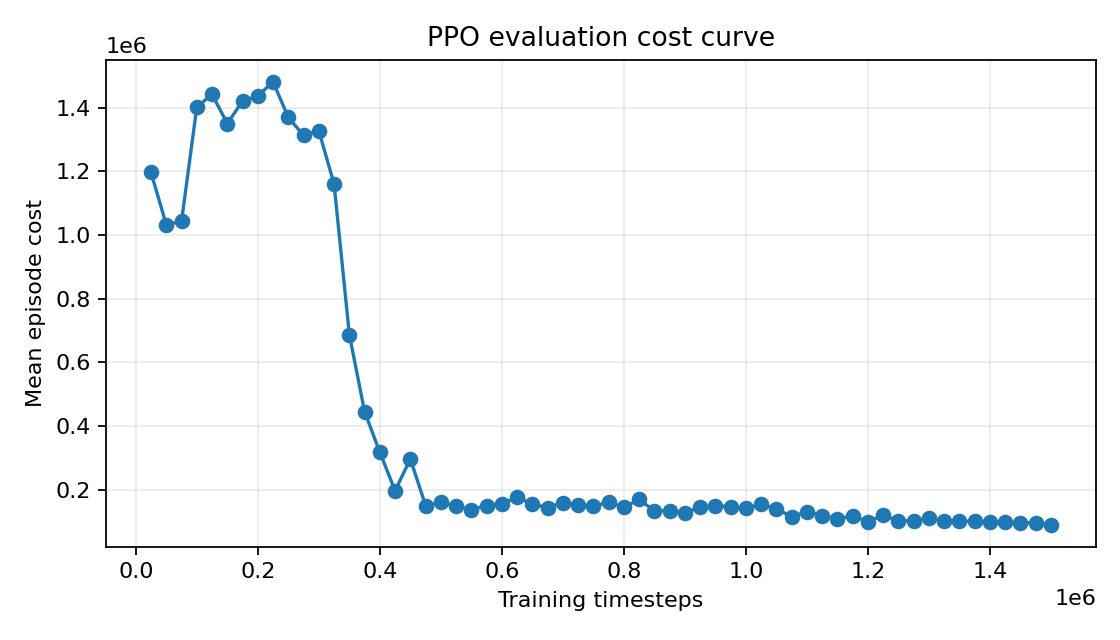

In [ ]:
from IPython.display import Image, display
display(Image(filename='results/ppo_learning_curve.png'))

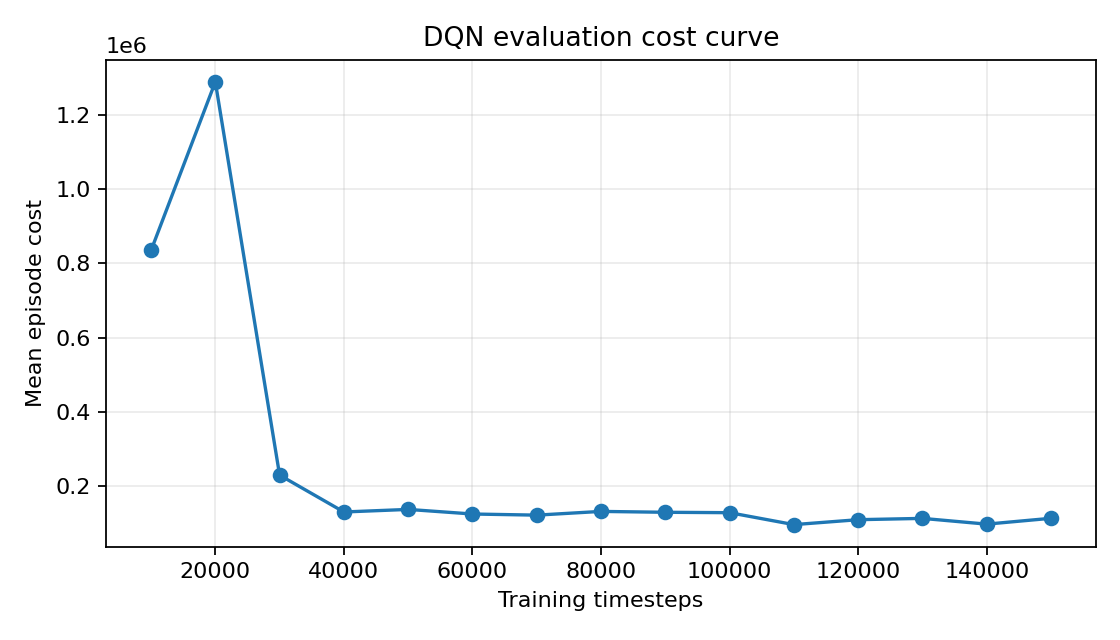

In [ ]:
from IPython.display import Image, display
display(Image(filename='results/dqn_learning_curve.png'))

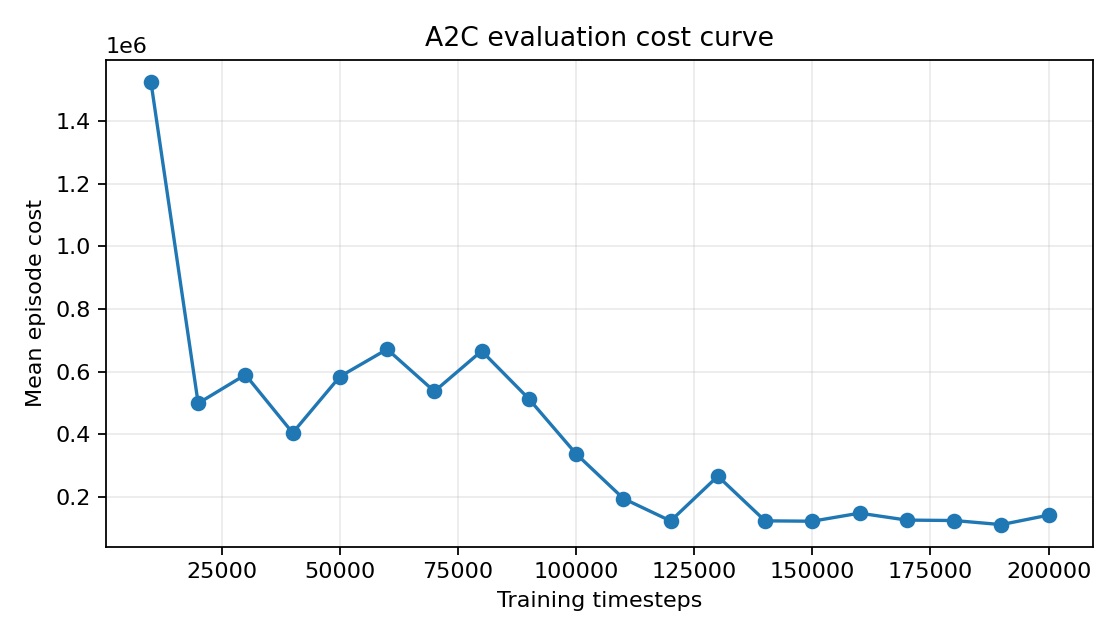

In [ ]:
from IPython.display import Image, display
display(Image(filename='results/a2c_learning_curve.png'))

For Neural Network SARSA and the final Double DQN submission, the preserved evidence is the
200-episode official local holdout and scenario breakdown. No time-series curve is fabricated
where the corresponding run did not preserve one.


In [ ]:
scenario_results = pd.read_csv('results/scenario_summary_final_candidates.csv')
scenario_results

## 9. Policy validation and export

Validate every frozen policy with the supplied local validator:

```bash
python policy_validation_tests.py submissions/ppo/policy.py
python policy_validation_tests.py submissions/dqn/policy.py
python policy_validation_tests.py submissions/neural_sarsa/policy.py
python policy_validation_tests.py submissions/a2c/policy.py
python policy_validation_tests.py submissions/double_dqn/policy.py
```

The final policies use deterministic inference, return exactly three valid quantities, load their
colocated model artifacts, and do not call the environment's `step()`/`reset()` from `run_policy()`.


## 10. Final technique-to-artifact mapping

| Technique | Policy | Model artifact | Portal package |
|---|---|---|---|
| PPO | `submissions/ppo/policy.py` | `model.zip` | `portal_uploads/ppo_submission_final.zip` |
| DQN | `submissions/dqn/policy.py` | `model.zip` | `portal_uploads/dqn_submission_final.zip` |
| Neural Network SARSA | `submissions/neural_sarsa/policy.py` | `model.zip` | `portal_uploads/neural_sarsa_submission_final.zip` |
| A2C | `submissions/a2c/policy.py` | `model.zip` | `portal_uploads/a2c_submission_final.zip` |
| Double DQN | `submissions/double_dqn/policy.py` | `model.zip` | `portal_uploads/double_dqn_submission_final.zip` |


## 11. Final selection notes

The newer Neural Network SARSA seed-20260826 candidate was **not** selected because its public
score was 115,082.25, worse than the retained public 113,072.38 submission.

Failed A3C, online neural Q-learning, REINFORCE, factorized DQN and other exploratory artifacts
are excluded from the final code tree and are not part of the five selected submissions.

The professor-provided `starter_notebook.ipynb` is retained in the final repository unchanged as supplied course material. It provides the approved configuration-generation workflow used to establish the assigned V030 variant. The generated configuration is frozen in `training_pipelines/assigned_config.json`, and the final experiments use that assigned configuration consistently.


## 12. Reproducibility

Use the project root as the working directory and the frozen V030 configuration. Keep the
official environment unchanged. The final five submitted techniques are PPO, DQN, Neural
Network SARSA, A2C and Double DQN. All final policy/model artifacts are colocated and the final
release contains no failed experiment checkpoints or stale experimental scripts.
